# Data Preparation for Classifiers
## Step 1: Name location of classes
Select one folder that contains one subfolder for each class. Each subbolder contains CSV files. Every CSV file represents one item. Items are named after what they are ("artist - title (year).extension.csv"). Items are chacterized by feature magnitudes. We have extracted 21 features from every time frame of each audio file.

In [1]:
import os
import glob

measCsv=r'C:\Users\t_ziemer\Desktop\techno-mfcc-u'
folds=glob.glob(str(measCsv+'\\*'))

## Step 2: List all features and select your preferred ones

In [2]:
# dictionary of all features:
features = {1: 'MFCC1',
            2: 'MFCC2',
            3: 'MFCC3',
            4: 'MFCC4',
            5: 'MFCC5',
            6: 'MFCC6',
            7: 'MFCC7',
            8: 'MFCC8',
            9: 'MFCC9',
            10: 'MFCC10',
            11: 'MFCC11',
            12: 'MFCC12',
            13: 'MFCC13',
            14: 'SpectralCentroid',
            15: 'SpectralRolloff',
            16: 'SpectralFlatness',
            17: 'SpectralBandwidth',
            18: 'ZeroCrossingRate'#,19:'bpm'
           }

# selection of preferred features
nfeatures = {0: 1,
             1: 2,
             2: 3,
             3: 4,
             4:5,
            5:6,
            6:7,
            7:10,
             8:11
            }
# shall we take each feratures' 'mean', 'median', standard deviation ('std'), skewness ('skew'), or kurtosis ('kurt')?
what=['median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median',
      'median'
     ]
numfeatures = len(nfeatures)

## Step 3: Prepare the training data matrix

In [3]:
import numpy as np # for arrays
import pandas as pd # for importing csv files
from pathlib import Path

train_X = np.array([np.zeros(numfeatures)])
target = []
color_map = {}
classname = []

for cl, fold in enumerate(folds):
    files = glob.glob(str(fold+'\*.csv'))
    numfiles = len(files)
    lal1 = np.empty((numfiles, numfeatures))
    for j, f in enumerate(files):
        la = pd.read_csv(f, index_col=0)
        # print(f)
        classname.append(cl)
        for dt, i in enumerate(nfeatures):
            if what[dt]=='std':
                lal1[j][i-1] = la[features[nfeatures[i]]].std()
            elif what[dt]=='mean':
                lal1[j][i-1] = la[features[nfeatures[i]]].mean()
            elif what[dt]=='median':
                lal1[j][i-1] = la[features[nfeatures[i]]].median()
            elif what[dt]=='skew':
                lal1[j][i-1] = la[features[nfeatures[i]]].skew()
            elif what[dt]=='kurt':
                lal1[j][i-1] = la[features[nfeatures[i]]].kurtosis()
            #if STD[dt]:
                # calculate standard deviation of feature over time
            #    lal1[j][i-1] = la[features[nfeatures[i]]].std()
            #else:
                # calculate mean of features over time
                #lal1[j][i-1] = la[features[nfeatures[i]]].mean()#!?!median()

    train_X = np.concatenate((train_X, lal1))
    target = target + [(str(Path(fold).relative_to(measCsv)), i+1)
                       for i in range(0, len(lal1))]

    color_map[str(Path(fold).relative_to(measCsv))] = cl

train_X = train_X[1:]

# give the classes their names
#labels = ['1984u', '1985g','1985u','1986g','1986u','1987g','1987u','1988g','1988u','1989g','1989u','1990g','1990u','1991g','1991u','1992g','1992u','1993g','1993u','1994g','1994u']
#labels=['Germany','USA']
#labels = ['Acid House', 'breakbeat', 'Chicago House', 'Deep House', 'Detroit Techno 1st', 'Detroit Techno 2nd', 'downbeat', 'Downbeat US', 'eurodance', 'Garage House', 'happy hardcore', 'hardcore', 'Hardcore US', 'hardtrance', 'Hip House', 'house', 'tekkno', 'trance']
#labels = [ 'breakbeat', 'downbeat','eurodance', 'happy hardcore', 'hardcore', 'hardtrance', 'house', 'tekkno', 'trance']
labels = ['Acid House', 'Chicago House', 'Deep House', 'Detroit Techno 1st', 'Detroit Techno 2nd', 'Downbeat US', 'Garage House', 'Hardcore US', 'Hip House']

Save training data and target to files:

In [4]:
target_df = pd.DataFrame(target)
target_df.to_csv('styles-MFCC-usa.csv', index=False, header=False)

In [5]:
train_X_df = pd.DataFrame(train_X)
train_X_df.to_csv('features-of-styles-MFCC-germany.csv', index=False, header=False)

In [6]:
cassname_df = pd.DataFrame(classname)
cassname_df.to_csv('stylenames-MFCC-germany.csv', index=False, header=False)

## Step 4: Scale the data

In [7]:
from sklearn import preprocessing #für normierung

scaler = preprocessing.StandardScaler().fit(train_X) #skalieren die einzelen features auf Mean=0 und Std=1
lal = scaler.transform(train_X)

Import scale data

In [10]:
#import pickle
#scalerpath = r'C:\python\gits\icmc\2025-12-23-MFCC1,3-7,10,11+bandwidth+zcr.pkl'
#scaler = pickle.load(open(scalerpath,'rb'))
#lal = scaler.transform(train_X)

## Step 5: Train-Test-Split

In [8]:
from sklearn.model_selection import train_test_split# splits the feature matrix into training data of test_size a

y=classname#each row includes the class number
X=lal# train_X# each row includes all attribute magnitudes of a single item
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=13)

## Step 6: Train and validate a classifier

### Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()#load an instance of the RF classifier
rf.fit(X_train, y_train)
print(f'Train Accuracy: {rf.score(X_train, y_train):.3f}')
print(f'Test Accuracy: {rf.score(X_test, y_test):.3f}')

Train Accuracy: 0.994
Test Accuracy: 0.267


              precision    recall  f1-score   support

           0       0.22      0.10      0.13        21
           1       0.23      0.11      0.15        28
           2       0.13      0.24      0.17        29
           3       0.35      0.32      0.34        37
           4       0.22      0.31      0.26        39
           5       0.40      0.11      0.17        18
           6       0.34      0.44      0.39        45
           7       0.29      0.29      0.29         7
           8       0.43      0.26      0.32        23

    accuracy                           0.27       247
   macro avg       0.29      0.24      0.25       247
weighted avg       0.29      0.27      0.26       247

Train Accuracy: 0.994
Test Accuracy: 0.267


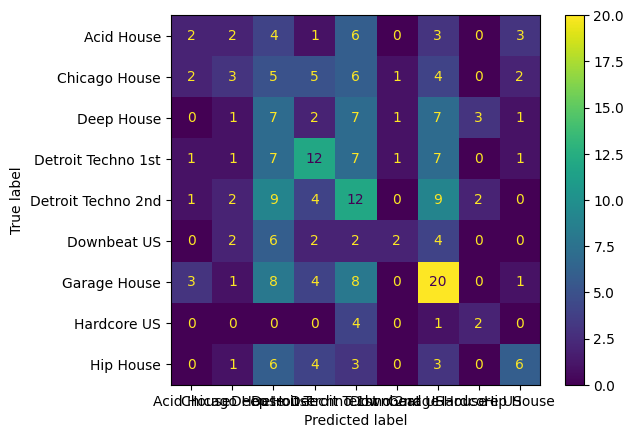

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_predict = rf.predict(X_test)
cmrf = confusion_matrix(y_test, rf_predict)
cmdrf = ConfusionMatrixDisplay(cmrf, display_labels=labels)
cmdrf.plot()
print(classification_report(y_test, rf_predict))
print(f'Train Accuracy: {rf.score(X_train, y_train):.3f}')
print(f'Test Accuracy: {rf.score(X_test, y_test):.3f}')

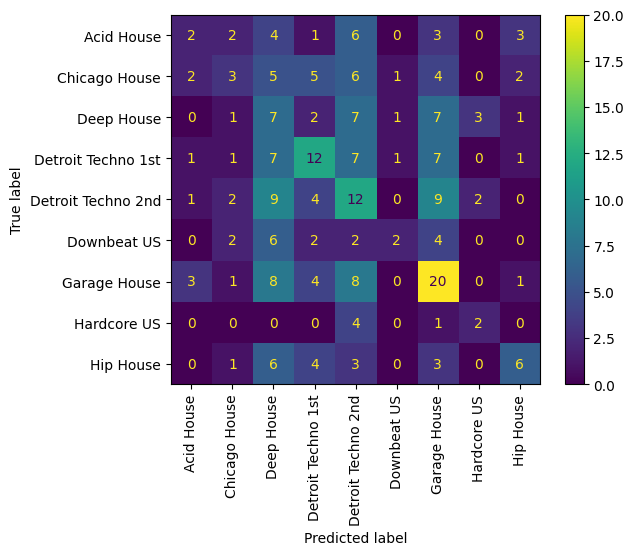

              precision    recall  f1-score   support

           0       0.22      0.10      0.13        21
           1       0.23      0.11      0.15        28
           2       0.13      0.24      0.17        29
           3       0.35      0.32      0.34        37
           4       0.22      0.31      0.26        39
           5       0.40      0.11      0.17        18
           6       0.34      0.44      0.39        45
           7       0.29      0.29      0.29         7
           8       0.43      0.26      0.32        23

    accuracy                           0.27       247
   macro avg       0.29      0.24      0.25       247
weighted avg       0.29      0.27      0.26       247

Train Accuracy: 0.994
Test Accuracy: 0.267


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

rf_predict = rf.predict(X_test)
cmrf = confusion_matrix(y_test, rf_predict)
cmdrf = ConfusionMatrixDisplay(cmrf, display_labels=labels)
cmdrf.plot()

# Rotate x-axis tick labels to vertical
import matplotlib.pyplot as plt
plt.xticks(rotation=90)

# Show the plot
plt.show()

print(classification_report(y_test, rf_predict))
print(f'Train Accuracy: {rf.score(X_train, y_train):.3f}')
print(f'Test Accuracy: {rf.score(X_test, y_test):.3f}')

Loop it:

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings # to suppress warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Initialize lists to store metrics
train_accuracies = []
test_accuracies = []
confusion_matrices = []
precision = []
recall = []
f1 = []

for i in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i,stratify=y)

    # Create and train the Random Forest classifier
    rf = RandomForestClassifier(random_state=i)
    rf.fit(X_train, y_train)

    # Make predictions on the test set
    rf_predict = rf.predict(X_test)

    # Calculate and store metrics
    train_accuracy = rf.score(X_train, y_train)
    test_accuracy = rf.score(X_test, y_test)
    cmrf = confusion_matrix(y_test, rf_predict)
    #cmrf = cmrf.astype('float') / cmrf.sum(axis=1)[:, np.newaxis] * 100  # Normalize to percentages
    cmdrf = ConfusionMatrixDisplay(cmrf,display_labels=labels)#
    #cmdrf.plot()
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    confusion_matrices.append(cmrf)
    precision.append(precision_score(y_test, rf_predict, average='weighted'))  # Adjust for binary/multi-class
    recall.append(recall_score(y_test, rf_predict, average='weighted'))         # Adjust for binary/multi-class
    f1.append(f1_score(y_test, rf_predict, average='weighted'))

# After the loop, you can average the metrics or analyze them further
plt.figure(figsize=(10, 8))
average_train_accuracy = np.mean(train_accuracies)
average_test_accuracy = np.mean(test_accuracies)
average_precision = np.mean(precision)
average_recall = np.mean(recall)
average_f1 = np.mean(f1)

print(f'Average Train Accuracy: {average_train_accuracy:.3f}')
print(f'Average Test Accuracy: {average_test_accuracy:.3f}')
print(f'Average Precision: {average_precision:.3f}')
print(f'Average Recall: {average_recall:.3f}')
print(f'Average f1: {average_f1:.3f}')

# Ensure all confusion matrices have the same shape before averaging
shapes = [cm.shape for cm in confusion_matrices]
unique_shapes = set(shapes)
print(f'Unique shapes in confusion matrices: {unique_shapes}')

average_confusion_matrix = np.mean(confusion_matrices, axis=0)
average_confusion_matrix = average_confusion_matrix.astype('float') / average_confusion_matrix.sum(axis=1)[:, np.newaxis] * 100
cmdrf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)  # Ensure labels match your classes
#cmdrf.plot()
plt.show()

Average Train Accuracy: 0.992
Average Test Accuracy: 0.267
Average Precision: 0.269
Average Recall: 0.267
Average f1: 0.259
Unique shapes in confusion matrices: {(9, 9)}


<Figure size 1000x800 with 0 Axes>

In [13]:
print(np.std(train_accuracies))
print(np.std(test_accuracies))
print(np.std(precision))
print(np.std(recall))
print(np.std(f1))

0.0021522398602243776
0.021186775924351094
0.02495032801971284
0.021186775924351094
0.021619816400086006


In [34]:
#labels = ['Acid House', 'Chicago House', 'Deep House', 'Detroit Techno 1st', 'Detroit Techno 2nd', 'Downbeat US', 'Garage House', 'Hardcore US', 'Hip House']

<Figure size 3200x2800 with 0 Axes>

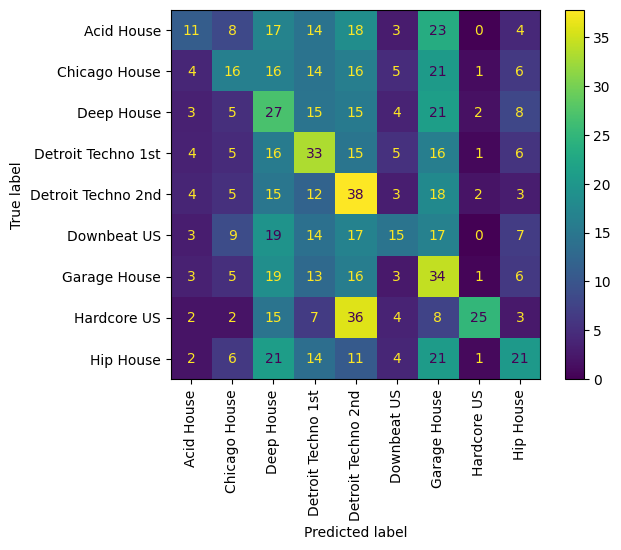

In [14]:
#%matplotlib inline
plt.figure(figsize=(16, 14),dpi=200)  # You can adjust these numbers to make it larger or smaller
cmdrf = ConfusionMatrixDisplay(average_confusion_matrix, display_labels=labels)
cmdrf.plot(values_format='.0f')  # Use values_format to control how the numbers are formatted
#plt.title('Average Confusion Matrix')  # Optional: Add a title
plt.xticks(rotation=90)
plt.savefig('rf100-MFCC-usa.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [68]:
target_df = pd.DataFrame(target)
target_df.to_csv('styles-Timbre-germany.csv', index=False, header=False)

train_X_df = pd.DataFrame(train_X)
train_X_df.to_csv('features-of-styles-Timbre-germany.csv', index=False, header=False)

cassname_df = pd.DataFrame(classname)
cassname_df.to_csv('stylenames-Timbre-germany.csv', index=False, header=False)